In [ ]:
import sys,os
#external packages
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
#custom packages
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''),"..")))
from im_net import datamanager, plotting
import datareader

%load_ext autoreload
%autoreload 2

In [25]:
plot_path="."
from cycler import cycler
from matplotlib.ticker import ScalarFormatter,FormatStrFormatter
plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.rcParams['text.usetex']=True
plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
plt.rcParams['svg.fonttype'] = 'none'
# pid_palette = ['#ea535a','#0066ac','#f2b315','#04cca6','#cadce0']
pid_palette = ['#ea535a','#0066ac','#9a26c8ff','#eebbeeff','#cadce0ff']
# paper_palette = ['#1a1a1aff','lightgray','#3ba3ecff',"darkkhaki",'#ff40ffff',]
paper_palette = ['#1a1a1aff','#d0a807ff','#406ee1ff',"#c93b9bff",'#1dbd68ff']
pid_cycler = cycler(color=pid_palette)

# Demo
This is a demo file showing how to train a Hopfield network on infomorphic goals.

## Step 1: Running the code
To quickly test whether your installation is working, run the following command from your console. 

```python src/training.py storage=full```

Make sure you run the code from a directory containing the "moebius.pkl" file.  This should produce the following code:

```python paper_hopfield/src/training.py 
Comment to run: debug
[2026-06-19 15:05:18,700][__main__][INFO] - Starting training for 100 epochs.
[2026-06-19 15:05:21,368][__main__][INFO] - finished training.█████████| 100.00% [100/100 00:02<00:00 Training, current loss=-95.97]
[2026-06-19 15:05:21,485][__main__][INFO] - Final accuracy is 1.00```

When executed without overrides, the code uses the parameters specified in conf/basic_config. This contains parameters like:
```
params:
  neurons: 100
  alpha: 0.2
  ```

So this will train with $p=\alpha N = 20$ patterns, below the memory capacity. Final accuracy is high.

## Step 2: Plotting run data:

Next, we will look at how to visualize data from completed runs. There are many metrics we can look at, but let's look at two important ones for now: performance during training and the PID atoms.

For this, we use the custom class Datamanager and give it the location of our data. Most data is stored in a .h5 file, which we read out using functions from the datamanager.

In [ ]:
# load datareader
path = '' #TODO
learningData=datamanager.DataManager(path,
									  mode='analysis', add_run_properties=True)
n_epochs=learningData.all['params.epochs'][0]
x_epochs=np.arange(0,n_epochs+1)
learningData.all

,test_val,date_dir,time_dir,multirun_id,run_path,comment,commit_hash,epochs_finished,finished,time_seconds,...,model.init.hebbian_init,model.layer1.biases,model.layer1.input_sizes,model.layer1.output_size,model.layer1.gamma,model.layer1.activation,model.layer1.activation_params.beta,model.layer1.discrete_output_values,model.layer1.self_connections,model.layer1.freeze_external
0,1,2026-06-19,15-56-47-540864,-1,/exp_names/Infomorphic/2026-...,debug,05eec9a279c3374fdbecb912218c37bcbf26b1be,100,True,24,...,False,"[False, False]","[${params.neurons}, ${params.neurons}]",${params.neurons},"[0, 0, 1, 0, 0]",im_net.activation_functions.SumActivation,1,"[-1, 1]",False,True


learningData.all is a Dataframe with metadata for all runs. Right now we are only looking at a single run, but later a folder with multiple runs can also be added (see README for details) and then filtered.

Next, let's extract our metrics and plot them. 

In [27]:
acc = datareader.group_data_to_numpy(learningData,'performance','acc')[0]

In [42]:
y_info=np.squeeze(datareader.pid_to_numpy(learningData),1)
labels = datareader.atom_names
y_info.shape

(5, 101, 100)

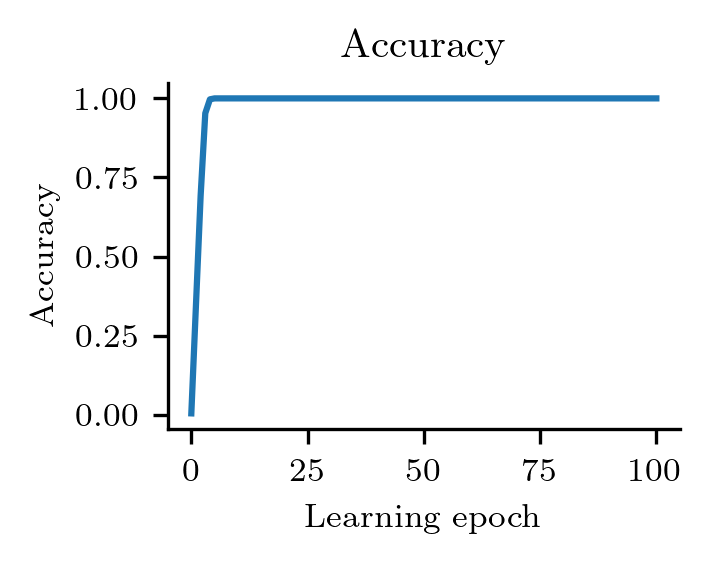

In [43]:
fig, ax = plt.subplots(1)
ax.set_xlabel(r"Learning epoch ")
ax.set_ylabel(r"Accuracy")
ax.set_title("Accuracy")
#fig.tight_layout()
ax.plot(x_epochs,acc)
#plotting.layout_performance(ax,(0,n_epochs),(0,20),x_log=False,show_legend=False)
plotting.standard_look(ax,ticks=False)
# ax.set_xscale('symlog')
#fig.savefig(f"{plot_path}/.pdf",bbox_inches="tight")

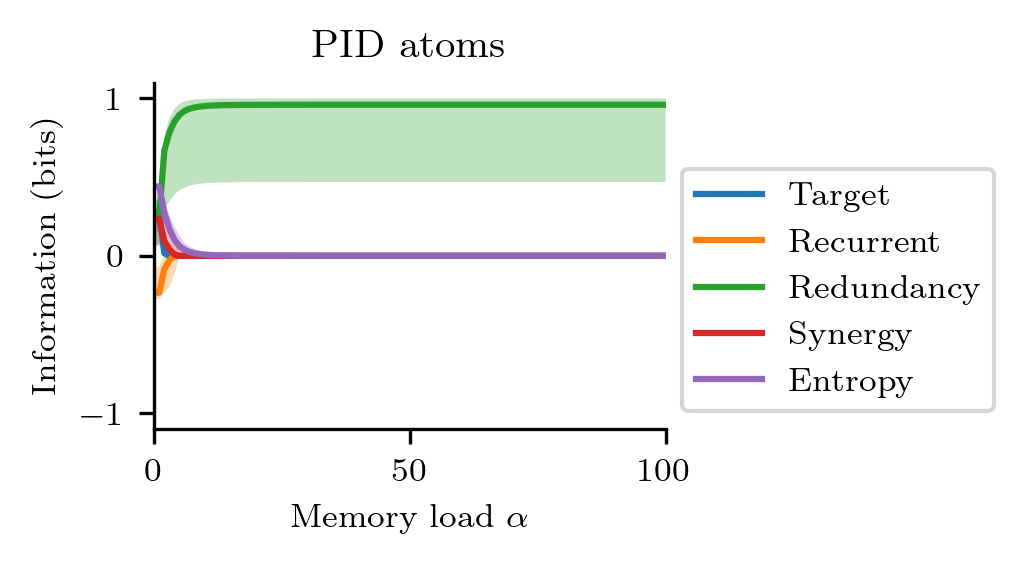

In [44]:
fig, ax = plt.subplots(1)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Information (bits)')
ax.set_title('PID atoms')
#fig.tight_layout()
for pid_atom,label in zip(y_info,labels):
    plotting.plot_mean_and_area(ax,x_epochs,pid_atom,label=label)
    
plotting.layout_performance(ax,(0,n_epochs),(-1,1),x_log=False)
# ax.set_xscale('symlog')
plotting.standard_look(ax,ticks=False)
ax.legend(bbox_to_anchor=(1,0.8))
# fig.savefig(f"{plot_path}/coinfo_pid_training.png",bbox_inches="tight")

## Step 3: Changing parameters

We use the hydra package for structured configs. Parameters of the run can be changed by adding options to the command. Try changing the amounts of patterns to a value above the memory capacity.

```python src/training.py params.alpha=1.9```

This should produce the following output:

```python paper_hopfield/src/training.py params.alpha=1.9
Comment to run: test
[2026-06-19 15:32:02,759][__main__][INFO] - Starting training for 100 epochs.
[2026-06-19 15:32:06,889][__main__][INFO] - finished training.█████████| 100.00% [100/100 00:04<00:00 Training, current loss=-82.42]
[2026-06-19 15:32:06,968][__main__][INFO] - Final accuracy is 0.02.```

This concludes the demo. Next, check out the notebooks in the folder ./plotting/  for reproducing the results of the paper. Each of them contains a list of overrides necessary to reproduce the results together with code to plot them. Good luck and have fun!